# VAE Training — Extended Features (CC1 + CC2 only)

**New notebook.** Input: `data/processed_extended/windows_cc1_extended/X_*.npy`
(26-dim whitened PCA windows, from the 11-feature extended set). Same
architecture-search methodology as `train_vae.ipynb` — beta search first (to
avoid the posterior-collapse trap found previously), then latent-dim ablation,
then full training — re-run fresh rather than assumed, since the input
distribution changed even though the component count happens to also be 26.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import pickle, os, time

torch.manual_seed(42)
np.random.seed(42)

BASE       = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3'
DATA_DIR   = os.path.join(BASE, 'experiments', 'models_extended', 'data', 'processed_extended', 'windows_cc1_extended')
MODEL_DIR  = os.path.join(BASE, 'experiments', 'models_extended', 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  Device: {DEVICE}')

SPLITS = ['cc1_train', 'cc1_val', 'cc1_test', 'drift_cc2']

HIDDEN1, HIDDEN2 = 64, 32
LATENT_CHOICES = [8, 16, 32]
BETA_CHOICES = [1.0, 0.1, 0.01, 0.001]
BETA_SEARCH_LATENT_DIM = 16
ABLATION_EPOCHS, ABLATION_PATIENCE = 40, 8
FULL_MAX_EPOCHS, FULL_PATIENCE = 300, 20
WARMUP_EPOCHS = 10
LR, BATCH_SIZE, CLIP = 1e-3, 512, 20.0

print('Hyperparameters configured.')

PyTorch 2.8.0+cpu  |  Device: cpu
Hyperparameters configured.


## Step 1 — Load data + sanity guard

In [2]:
raw = {name: np.load(os.path.join(DATA_DIR, f'X_{name}.npy')) for name in SPLITS}
labels = {name: np.load(os.path.join(DATA_DIR, f'y_{name}.npy')) for name in SPLITS}

INPUT_DIM = raw['cc1_train'].shape[1]
print(f'INPUT_DIM = {INPUT_DIM}')

for name, X in raw.items():
    assert X.shape[1] == INPUT_DIM, f'{name}: dim mismatch'
    assert not np.isnan(X).any(), f'{name}: contains NaN'
    assert not np.isinf(X).any(), f'{name}: contains Inf'
assert (labels['cc1_train'] == 0).all(), 'cc1_train contains labeled anomalies'
print('Sanity checks passed.')

data = {name: np.clip(X, -CLIP, CLIP).astype(np.float32) for name, X in raw.items()}
X_train_t = torch.from_numpy(data['cc1_train'])
X_val_t   = torch.from_numpy(data['cc1_val'])
print(f'X_train: {X_train_t.shape}   X_val: {X_val_t.shape}')

INPUT_DIM = 26
Sanity checks passed.
X_train: torch.Size([154198, 26])   X_val: torch.Size([21573, 26])


## Step 2 — VAE class + loss (identical design to `train_vae.ipynb`, KL bug already fixed)

In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, hidden1), nn.ReLU(), nn.Linear(hidden1, hidden2), nn.ReLU())
        self.fc_mu = nn.Linear(hidden2, latent_dim)
        self.fc_lv = nn.Linear(hidden2, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, hidden2), nn.ReLU(), nn.Linear(hidden2, hidden1), nn.ReLU(), nn.Linear(hidden1, input_dim))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
    def encode(self, x):
        h = self.encoder(x); return self.fc_mu(h), torch.clamp(self.fc_lv(h), -10, 10)
    def decode(self, z): return self.decoder(z)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar); return mu + torch.randn_like(std) * std
    def forward(self, x):
        mu, logvar = self.encode(x); z = self.reparameterize(mu, logvar); return self.decode(z), mu, logvar
    @torch.no_grad()
    def anomaly_score(self, x):
        self.eval(); mu, _ = self.encode(x); return ((self.decode(mu) - x) ** 2).mean(dim=1)

def vae_loss(recon, x, mu, logvar, beta):
    recon_loss = nn.functional.mse_loss(recon, x, reduction='mean')
    kl = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    return recon_loss + beta * kl, recon_loss, kl

print('VAE class defined.')

VAE class defined.


## Step 3 — Training loop

In [4]:
def train_vae(latent_dim, max_epochs, patience, beta_max, verbose=False):
    torch.manual_seed(42)
    model = VAE(INPUT_DIM, HIDDEN1, HIDDEN2, latent_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loader = DataLoader(TensorDataset(X_train_t), batch_size=BATCH_SIZE, shuffle=True)

    history = {k: [] for k in ['train_loss', 'val_loss', 'train_recon', 'val_recon', 'train_kl', 'val_kl']}
    best_val, best_state, patience_ctr = float('inf'), None, 0

    for epoch in range(max_epochs):
        beta = min(1.0, (epoch + 1) / WARMUP_EPOCHS) * beta_max
        model.train()
        tr_loss = tr_recon = tr_kl = 0.0
        n = 0
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            opt.zero_grad()
            recon, mu, logvar = model(xb)
            loss, rloss, kl = vae_loss(recon, xb, mu, logvar, beta)
            loss.backward(); opt.step()
            bs = xb.size(0)
            tr_loss += loss.item() * bs; tr_recon += rloss.item() * bs; tr_kl += kl.item() * bs; n += bs
        tr_loss /= n; tr_recon /= n; tr_kl /= n

        model.eval()
        with torch.no_grad():
            recon, mu, logvar = model(X_val_t.to(DEVICE))
            vloss, vrecon, vkl = vae_loss(recon, X_val_t.to(DEVICE), mu, logvar, beta)

        history['train_loss'].append(tr_loss); history['val_loss'].append(vloss.item())
        history['train_recon'].append(tr_recon); history['val_recon'].append(vrecon.item())
        history['train_kl'].append(tr_kl); history['val_kl'].append(vkl.item())

        if vloss.item() < best_val - 1e-6:
            best_val, best_state, patience_ctr = vloss.item(), {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                if verbose: print(f'    early stop at epoch {epoch+1} (best val_loss={best_val:.4f})')
                break
        if verbose and (epoch % 10 == 0 or epoch == max_epochs - 1):
            print(f'    epoch {epoch+1:3d}  beta={beta:.3f}  train={tr_loss:.4f} (recon={tr_recon:.4f} kl={tr_kl:.4f})  val={vloss.item():.4f}')

    model.load_state_dict(best_state)
    return model, history, best_val

print('Training function defined.')

Training function defined.


## Step 4a — Beta search

In [5]:
beta_search = {}
for b in BETA_CHOICES:
    print(f'  beta_max={b} ...')
    _, history, best_val = train_vae(BETA_SEARCH_LATENT_DIM, ABLATION_EPOCHS, ABLATION_PATIENCE, beta_max=b)
    final_recon, final_kl = history['train_recon'][-1], history['train_kl'][-1]
    collapsed = final_kl < 0.05
    beta_search[b] = {'best_val': best_val, 'final_recon': final_recon, 'final_kl': final_kl, 'collapsed': collapsed}
    print(f'    final_recon={final_recon:.4f}  final_kl={final_kl:.4f}  {"COLLAPSED" if collapsed else "ok"}')

candidates = [b for b, r in beta_search.items() if not r['collapsed']]
assert candidates, 'Every beta_max candidate collapsed.'
BEST_BETA_MAX = max(candidates)
print(f'\nChosen beta_max = {BEST_BETA_MAX}')

  beta_max=1.0 ...
    final_recon=0.9969  final_kl=0.0001  COLLAPSED
  beta_max=0.1 ...
    final_recon=0.9288  final_kl=0.3687  ok
  beta_max=0.01 ...
    final_recon=0.1101  final_kl=18.4282  ok
  beta_max=0.001 ...
    final_recon=0.0375  final_kl=43.6894  ok

Chosen beta_max = 0.1


## Step 4b — Latent-dimension ablation

In [6]:
ablation_results = {}
for ld in LATENT_CHOICES:
    print(f'  latent_dim={ld} ...')
    t0 = time.time()
    _, history, best_val = train_vae(ld, ABLATION_EPOCHS, ABLATION_PATIENCE, beta_max=BEST_BETA_MAX)
    ablation_results[ld] = {'best_val': best_val, 'time': time.time() - t0, 'final_kl': history['train_kl'][-1]}
    print(f'    best_val_loss={best_val:.4f}  final_kl={history["train_kl"][-1]:.4f}  ({ablation_results[ld]["time"]:.1f}s)')

BEST_LATENT_DIM = min(ablation_results, key=lambda k: ablation_results[k]['best_val'])
print(f'\nChosen latent_dim = {BEST_LATENT_DIM}')

  latent_dim=8 ...
    best_val_loss=0.9502  final_kl=0.8806  (169.0s)
  latent_dim=16 ...
    best_val_loss=0.9997  final_kl=0.3687  (169.9s)
  latent_dim=32 ...
    best_val_loss=1.0059  final_kl=0.0003  (116.2s)

Chosen latent_dim = 8


## Step 5 — Full training

Training final VAE: latent_dim=8, beta_max=0.1 ...
    epoch   1  beta=0.010  train=3.6145 (recon=3.4810 kl=13.3465)  val=1.1208
    epoch  11  beta=0.100  train=1.0233 (recon=0.9783 kl=0.4496)  val=1.0361
    epoch  21  beta=0.100  train=0.9708 (recon=0.9211 kl=0.4967)  val=1.0033
    epoch  31  beta=0.100  train=0.9046 (recon=0.8183 kl=0.8629)  val=0.9614
    epoch  41  beta=0.100  train=0.8897 (recon=0.8014 kl=0.8827)  val=0.9508
    epoch  51  beta=0.100  train=0.8843 (recon=0.7952 kl=0.8903)  val=0.9457
    epoch  61  beta=0.100  train=0.8773 (recon=0.7828 kl=0.9443)  val=0.9426
    epoch  71  beta=0.100  train=0.8724 (recon=0.7757 kl=0.9672)  val=0.9378
    epoch  81  beta=0.100  train=0.8709 (recon=0.7732 kl=0.9765)  val=0.9357
    epoch  91  beta=0.100  train=0.8692 (recon=0.7716 kl=0.9764)  val=0.9366
    epoch 101  beta=0.100  train=0.8691 (recon=0.7718 kl=0.9735)  val=0.9345
    epoch 111  beta=0.100  train=0.8679 (recon=0.7700 kl=0.9793)  val=0.9324
    epoch 121  beta=0.10

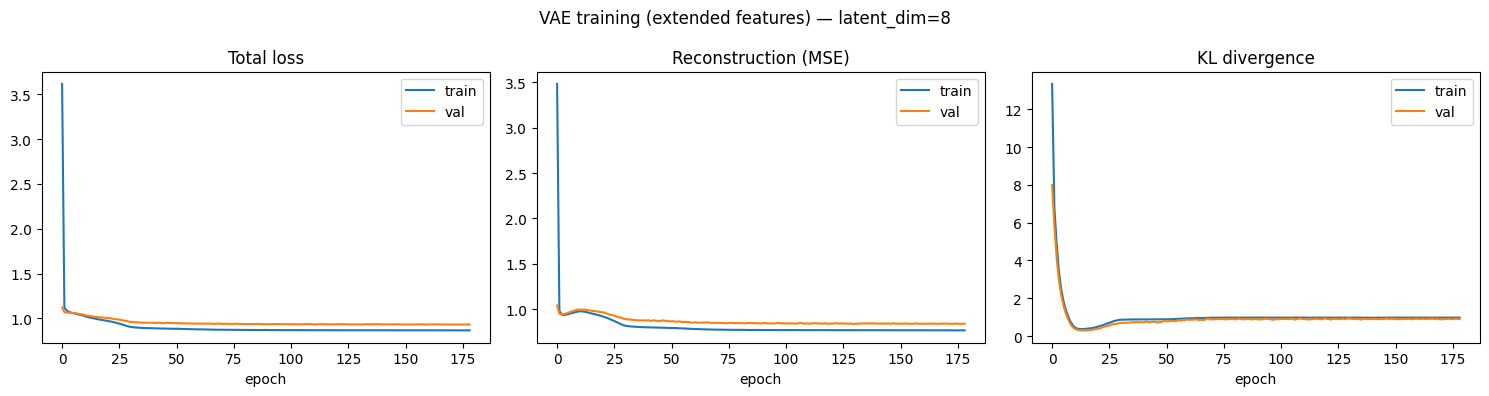

In [7]:
print(f'Training final VAE: latent_dim={BEST_LATENT_DIM}, beta_max={BEST_BETA_MAX} ...')
model, history, best_val = train_vae(BEST_LATENT_DIM, FULL_MAX_EPOCHS, FULL_PATIENCE, beta_max=BEST_BETA_MAX, verbose=True)
print(f'\nFinal best val loss: {best_val:.4f}  |  epochs run: {len(history["train_loss"])}')
final_kl = history['train_kl'][-1]
print(f'Final train KL: {final_kl:.4f}  ({"WARNING: looks collapsed" if final_kl < 0.05 else "non-trivial, ok"})')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ['train_loss', 'train_recon', 'train_kl'], ['Total loss', 'Reconstruction (MSE)', 'KL divergence']):
    ax.plot(history[key], label='train'); ax.plot(history[key.replace('train', 'val')], label='val')
    ax.set_title(title); ax.set_xlabel('epoch'); ax.legend()
plt.suptitle(f'VAE training (extended features) — latent_dim={BEST_LATENT_DIM}')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_cc1_extended_training_curves.png'), dpi=120)
plt.show()

## Step 6 — Train-MSE baseline + directional sanity check

In [8]:
with torch.no_grad():
    mse_train = model.anomaly_score(X_train_t.to(DEVICE)).cpu().numpy()
    mse_val   = model.anomaly_score(X_val_t.to(DEVICE)).cpu().numpy()
mu_train, sigma_train = float(mse_train.mean()), float(mse_train.std())
print(f'cc1_train MSE: mean={mu_train:.5f}  std={sigma_train:.5f}')
print(f'cc1_val   MSE: mean={mse_val.mean():.5f}  std={mse_val.std():.5f}')

print(f'\n{"set":12s} {"normal_mean_mse":>16s} {"anomaly_mean_mse":>17s} {"ratio":>8s}')
for name in ['cc1_test', 'drift_cc2']:
    X = torch.from_numpy(data[name]).to(DEVICE)
    y = labels[name]
    with torch.no_grad():
        mse = model.anomaly_score(X).cpu().numpy()
    normal_mse = mse[y == 0].mean()
    anom_mse = mse[y == 1].mean() if (y == 1).any() else float('nan')
    print(f'{name:12s} {normal_mse:16.5f} {anom_mse:17.5f} {anom_mse/normal_mse:8.2f}x')

cc1_train MSE: mean=0.73721  std=0.58058
cc1_val   MSE: mean=0.80940  std=0.66428

set           normal_mean_mse  anomaly_mean_mse    ratio
cc1_test              0.74697           2.35812     3.16x
drift_cc2             1.74217           2.93771     1.69x


## Step 7 — Save

In [9]:
model_path = os.path.join(MODEL_DIR, 'vae_cc1_extended.pt')
torch.save(model.state_dict(), model_path)

meta = {
    'input_dim': INPUT_DIM, 'hidden1': HIDDEN1, 'hidden2': HIDDEN2, 'latent_dim': BEST_LATENT_DIM,
    'beta_max': BEST_BETA_MAX, 'clip': CLIP, 'mu_train': mu_train, 'sigma_train': sigma_train,
    'beta_search': beta_search, 'ablation': {ld: r['best_val'] for ld, r in ablation_results.items()},
    'feature_cols': ['container_cpu_usage_seconds_rate', 'container_cpu_system_seconds_rate', 'container_cpu_user_seconds_rate',
                     'container_cpu_cfs_throttled_seconds_rate', 'container_cpu_cfs_throttled_periods_rate',
                     'container_memory_usage_bytes', 'container_memory_working_set_bytes', 'container_memory_rss',
                     'container_memory_cache', 'container_threads', 'memory_limit_proximity'],
}
meta_path = os.path.join(MODEL_DIR, 'vae_cc1_extended_meta.pkl')
with open(meta_path, 'wb') as f:
    pickle.dump(meta, f)
print(f'Model saved -> {model_path}')
print(f'Metadata saved -> {meta_path}')

Model saved -> c:\Users\jthar\Documents\Claude\Projects\module3\models_extended\vae_cc1_extended.pt
Metadata saved -> c:\Users\jthar\Documents\Claude\Projects\module3\models_extended\vae_cc1_extended_meta.pkl
